In [2]:
pip install matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 5.4 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 5.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 7.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 7.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (col,desc,avg,sum,count,min,max)
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
spark = (SparkSession.builder.appName("GlobalClimateVolatility-Notebook").master("local[2]").getOrCreate())
print("Spark session started successfully.")

Spark session started successfully.


In [8]:
monthly_path = "../data/processed/monthly/2024"

monthly_df = spark.read.parquet(monthly_path)

print("Monthly records:", monthly_df.count())
print("Monthly columns:", len(monthly_df.columns))

monthly_df.printSchema()

Monthly records: 120
Monthly columns: 15
root
 |-- STATION: integer (nullable = true)
 |-- NAME: string (nullable = true)
 |-- LATITUDE: double (nullable = true)
 |-- LONGITUDE: double (nullable = true)
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- TOTAL_DAYS: long (nullable = true)
 |-- HIGH_VOLATILITY_DAYS: long (nullable = true)
 |-- HIGH_VOLATILITY_RATE: double (nullable = true)
 |-- AVG_VOLATILITY_SCORE: double (nullable = true)
 |-- MAX_VOLATILITY_SCORE: double (nullable = true)
 |-- AVG_TEMP_ANOMALY: double (nullable = true)
 |-- AVG_TEMP_VOLATILITY: double (nullable = true)
 |-- AVG_PRCP_VOLATILITY: double (nullable = true)
 |-- AVG_WIND_VOLATILITY: double (nullable = true)



In [9]:
monthly_df.show(5, truncate=False)

+----------+-----------------+---------+----------+----+-----+----------+--------------------+--------------------+--------------------+--------------------+-------------------+-------------------+--------------------+--------------------+
|STATION   |NAME             |LATITUDE |LONGITUDE |YEAR|MONTH|TOTAL_DAYS|HIGH_VOLATILITY_DAYS|HIGH_VOLATILITY_RATE|AVG_VOLATILITY_SCORE|MAX_VOLATILITY_SCORE|AVG_TEMP_ANOMALY   |AVG_TEMP_VOLATILITY|AVG_PRCP_VOLATILITY |AVG_WIND_VOLATILITY |
+----------+-----------------+---------+----------+----+-----+----------+--------------------+--------------------+--------------------+--------------------+-------------------+-------------------+--------------------+--------------------+
|1002099999|VERLEGENHUKEN, NO|80.05    |16.25     |2024|1    |22        |1                   |0.047619047619047616|0.5446411762067374  |1.2000019349273519  |-18.554545454545455|1.661663297745202  |-0.493550274970427  |-0.39977287144913276|
|1006099999|EDGEOYA, NO      |78.25    |

In [10]:
quality_df = monthly_df.select([sum(col(c).isNull().cast("int")).alias(c) for c in monthly_df.columns])

quality_df.show(truncate=False)

+-------+----+--------+---------+----+-----+----------+--------------------+--------------------+--------------------+--------------------+----------------+-------------------+-------------------+-------------------+
|STATION|NAME|LATITUDE|LONGITUDE|YEAR|MONTH|TOTAL_DAYS|HIGH_VOLATILITY_DAYS|HIGH_VOLATILITY_RATE|AVG_VOLATILITY_SCORE|MAX_VOLATILITY_SCORE|AVG_TEMP_ANOMALY|AVG_TEMP_VOLATILITY|AVG_PRCP_VOLATILITY|AVG_WIND_VOLATILITY|
+-------+----+--------+---------+----+-----+----------+--------------------+--------------------+--------------------+--------------------+----------------+-------------------+-------------------+-------------------+
|0      |0   |0       |0        |0   |0    |0         |0                   |0                   |0                   |0                   |0               |0                  |0                  |0                  |
+-------+----+--------+---------+----+-----+----------+--------------------+--------------------+--------------------+--------------

In [11]:
print("Total monthly records:", monthly_df.count())
print("Unique stations:", monthly_df.select("STATION").distinct().count())
print("Unique months:", monthly_df.select("MONTH").distinct().count())
print("Year:", monthly_df.select("YEAR").distinct().collect()[0][0])

Total monthly records: 120
Unique stations: 10
Unique months: 12
Year: 2024


In [12]:
overall_stats = monthly_df.select(
    avg("HIGH_VOLATILITY_RATE").alias("Average High-Volatility Rate"),
    min("HIGH_VOLATILITY_RATE").alias("Minimum High-Volatility Rate"),
    max("HIGH_VOLATILITY_RATE").alias("Maximum High-Volatility Rate"),
    avg("AVG_VOLATILITY_SCORE").alias("Average Volatility Score"),
    min("AVG_VOLATILITY_SCORE").alias("Minimum Volatility Score"),
    max("AVG_VOLATILITY_SCORE").alias("Maximum Volatility Score")
)

overall_stats.show()

+----------------------------+----------------------------+----------------------------+------------------------+------------------------+------------------------+
|Average High-Volatility Rate|Minimum High-Volatility Rate|Maximum High-Volatility Rate|Average Volatility Score|Minimum Volatility Score|Maximum Volatility Score|
+----------------------------+----------------------------+----------------------------+------------------------+------------------------+------------------------+
|         0.06159505669401059|                         0.0|          0.6363636363636364|     0.20350312439162346|     -0.5535412505544811|      1.1321243088289348|
+----------------------------+----------------------------+----------------------------+------------------------+------------------------+------------------------+



In [13]:
top_events = (monthly_df.orderBy(desc("AVG_VOLATILITY_SCORE")).select("STATION","NAME","YEAR","MONTH","AVG_VOLATILITY_SCORE","MAX_VOLATILITY_SCORE","HIGH_VOLATILITY_DAYS","HIGH_VOLATILITY_RATE"))

top_events.show(10, truncate=False)

+----------+-----------------+----+-----+--------------------+--------------------+--------------------+--------------------+
|STATION   |NAME             |YEAR|MONTH|AVG_VOLATILITY_SCORE|MAX_VOLATILITY_SCORE|HIGH_VOLATILITY_DAYS|HIGH_VOLATILITY_RATE|
+----------+-----------------+----+-----+--------------------+--------------------+--------------------+--------------------+
|1011099999|KVITOYA, SV      |2024|1    |1.1321243088289348  |1.952530190519353   |14                  |0.6363636363636364  |
|1010099999|ANDOYA, NO       |2024|11   |0.8393171933595371  |2.175029835494612   |7                   |0.2692307692307692  |
|1003099999|HORNSUND, NO     |2024|12   |0.8282265613613198  |1.4747258932522929  |9                   |0.3                 |
|1009099999|KARL XII OYA, SV |2024|1    |0.7869824762339294  |1.9719681351803744  |11                  |0.36666666666666664 |
|1011099999|KVITOYA, SV      |2024|3    |0.7784830288790284  |2.0726067029990523  |6                   |0.285714285714

In [14]:
station_summary=(monthly_df.groupBy("STATION", "NAME").agg(avg("AVG_VOLATILITY_SCORE").alias("AVG_VOLATILITY_SCORE"),sum("HIGH_VOLATILITY_DAYS").alias("HIGH_VOLATILITY_DAYS"),avg("HIGH_VOLATILITY_RATE").alias("AVG_HIGH_VOLATILITY_RATE")).orderBy(desc("AVG_VOLATILITY_SCORE"))
)

station_summary.show(10, truncate=False)

+----------+----------------------+---------------------+--------------------+------------------------+
|STATION   |NAME                  |AVG_VOLATILITY_SCORE |HIGH_VOLATILITY_DAYS|AVG_HIGH_VOLATILITY_RATE|
+----------+----------------------+---------------------+--------------------+------------------------+
|1003099999|HORNSUND, NO          |0.38191387924963743  |29                  |0.08310127745611616     |
|1011099999|KVITOYA, SV           |0.328957513060663    |29                  |0.11774891774891776     |
|1007099999|NY ALESUND, SV        |0.24577291883919472  |39                  |0.10847610415648977     |
|1002099999|VERLEGENHUKEN, NO     |0.22912060464504655  |7                   |0.038938492063492064    |
|1010099999|ANDOYA, NO            |0.22828958478970338  |31                  |0.08977306218685528     |
|1006099999|EDGEOYA, NO           |0.210869599551191    |11                  |0.04715608465608465     |
|1001099999|JAN MAYEN NOR NAVY, NO|0.17205053123108607  |16     

/home/gururaman14/diss-venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/gururaman14/diss-venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


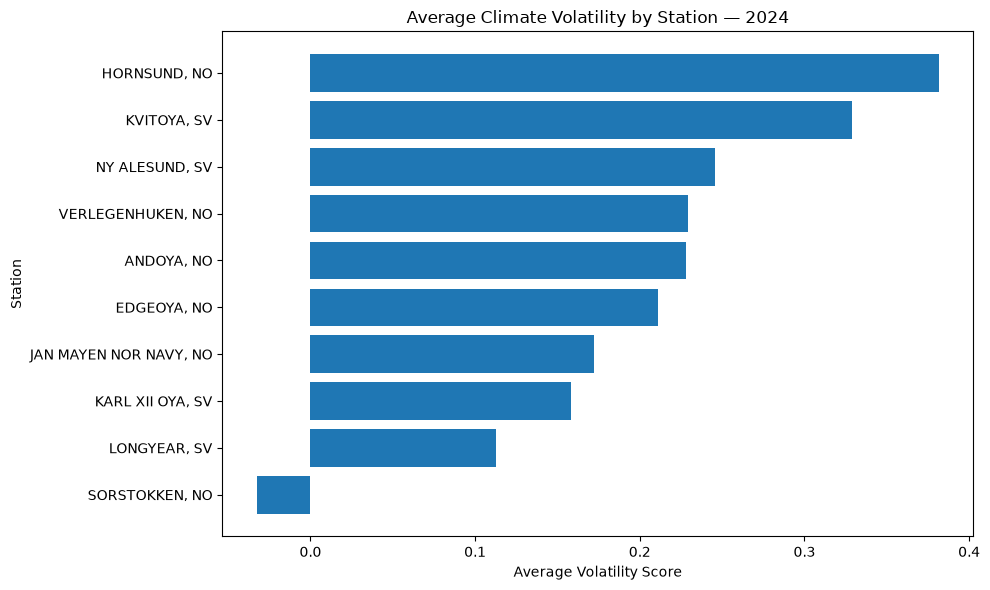

In [15]:
station_pd = station_summary.toPandas()
plt.figure(figsize=(10, 6))
plt.barh(station_pd["NAME"],station_pd["AVG_VOLATILITY_SCORE"])
plt.xlabel("Average Volatility Score")
plt.ylabel("Station")
plt.title("Average Climate Volatility by Station — 2024")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

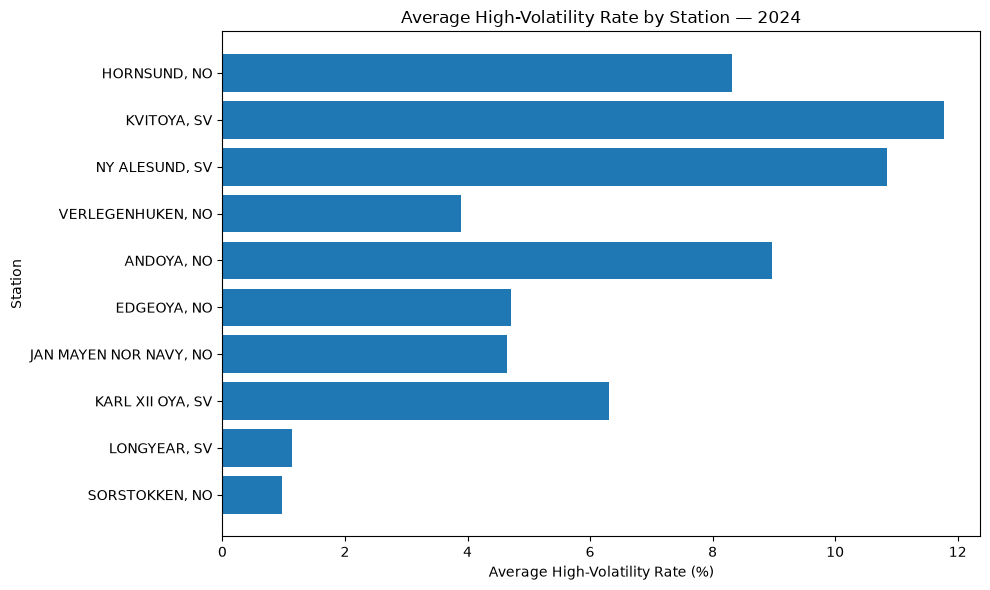

In [16]:
plt.figure(figsize=(10, 6))
plt.barh(station_pd["NAME"],station_pd["AVG_HIGH_VOLATILITY_RATE"]*100)
plt.xlabel("Average High-Volatility Rate (%)")
plt.ylabel("Station")
plt.title("Average High-Volatility Rate by Station — 2024")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
monthly_pattern = (monthly_df.groupBy("MONTH").agg(avg("HIGH_VOLATILITY_RATE").alias("AVG_HIGH_VOLATILITY_RATE"),avg("AVG_VOLATILITY_SCORE").alias("AVG_VOLATILITY_SCORE"),sum("HIGH_VOLATILITY_DAYS").alias("HIGH_VOLATILITY_DAYS")).orderBy("MONTH"))

monthly_pattern.show(12)

+-----+------------------------+--------------------+--------------------+
|MONTH|AVG_HIGH_VOLATILITY_RATE|AVG_VOLATILITY_SCORE|HIGH_VOLATILITY_DAYS|
+-----+------------------------+--------------------+--------------------+
|    1|     0.19872619267142594|  0.6337610007632622|                  52|
|    2|     0.04482758620689655| 0.23893410321985123|                  13|
|    3|     0.15009523809523811| 0.43783651640862625|                  30|
|    4|    0.062063492063492064| 0.27882230964066873|                  14|
|    5|                     0.0|  -0.043966679617596|                   0|
|    6|    0.023333333333333334|-0.06633042078985685|                   7|
|    7|                     0.0| -0.0732342466643293|                   0|
|    8|    0.006666666666666666| 0.06914400172715383|                   2|
|    9|                    0.01| 0.10787217144486179|                   3|
|   10|     0.05161290322580645|  0.1329897428686887|                  16|
|   11|     0.06181526806

In [18]:
seasonal_pd = monthly_pattern.toPandas()

seasonal_pd

/home/gururaman14/diss-venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/gururaman14/diss-venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,MONTH,AVG_HIGH_VOLATILITY_RATE,AVG_VOLATILITY_SCORE,HIGH_VOLATILITY_DAYS
0,1,0.198726,0.633761,52
1,2,0.044828,0.238934,13
2,3,0.150095,0.437837,30
3,4,0.062063,0.278822,14
4,5,0.000000,-0.043967,0
5,6,0.023333,-0.066330,7
6,7,0.000000,-0.073234,0
7,8,0.006667,0.069144,2
8,9,0.010000,0.107872,3
9,10,0.051613,0.132990,16


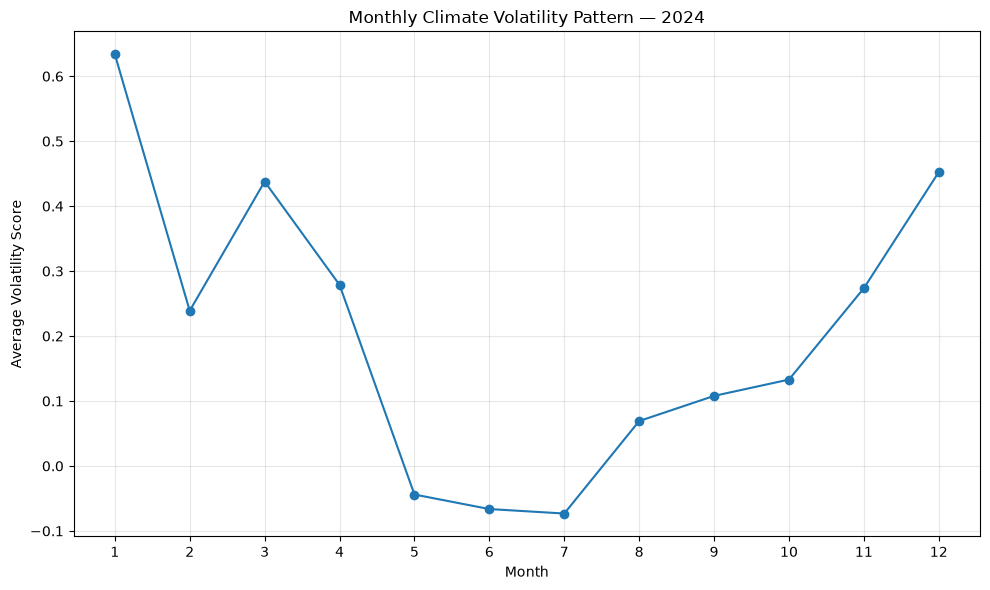

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(seasonal_pd["MONTH"],seasonal_pd["AVG_VOLATILITY_SCORE"],marker="o")
plt.xlabel("Month")
plt.ylabel("Average Volatility Score")
plt.title("Monthly Climate Volatility Pattern — 2024")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

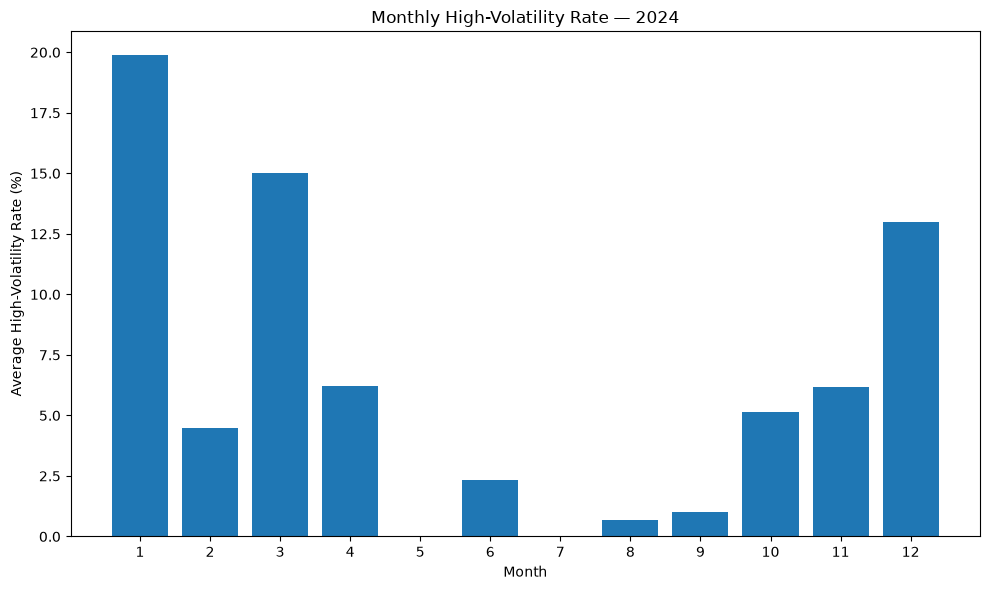

In [20]:
plt.figure(figsize=(10, 6))
plt.bar(seasonal_pd["MONTH"],seasonal_pd["AVG_HIGH_VOLATILITY_RATE"] * 100)
plt.xlabel("Month")
plt.ylabel("Average High-Volatility Rate (%)")
plt.title("Monthly High-Volatility Rate — 2024")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()